In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("telco.csv")
print(df.shape)     
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##### TotalCharges is object (text) will fix later.
##### 26.5% churn — imbalanced -> accuracy will mislead.


In [3]:
df.info()                                         
print(df["Churn"].value_counts(normalize=True)*100)    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


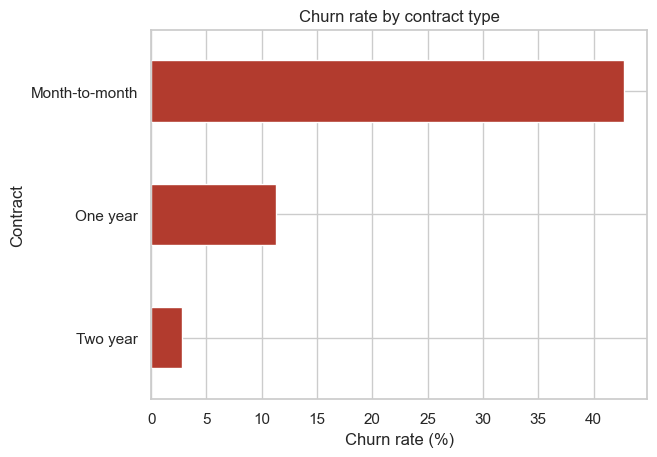

In [4]:
# Step 1: turn Churn into numbers — "Yes" becomes 1, "No" becomes 0
df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)

# Step 2: for each Contract type, find the average of ChurnFlag
#         (average of 1s and 0s = the fraction that churned = churn rate)
churn_by_contract = df.groupby("Contract")["ChurnFlag"].mean()

# Step 3: turn the fraction into a percentage and sort from low to high
churn_by_contract = (churn_by_contract * 100).sort_values()

# Step 4: show it as a horizontal bar chart
churn_by_contract.plot(kind="barh", color="#b23b2e")
plt.xlabel("Churn rate (%)")
plt.title("Churn rate by contract type")
plt.show()

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


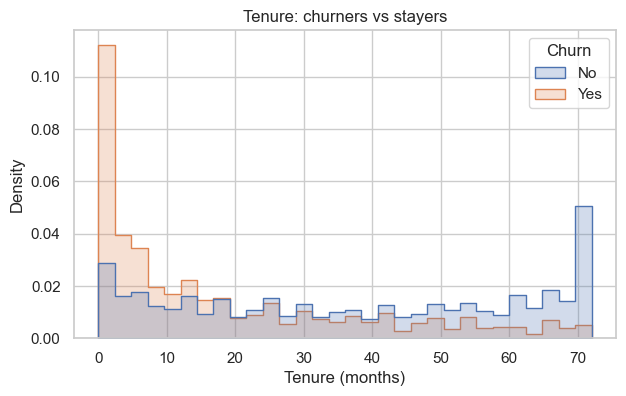

In [6]:
# Split customers into churned vs stayed, and compare their tenure
plt.figure(figsize=(7,4))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30,
             element="step", stat="density", common_norm=False)
plt.title("Tenure: churners vs stayers")
plt.xlabel("Tenure (months)")
plt.show()

#### new customers leave; long-time customers rarely do

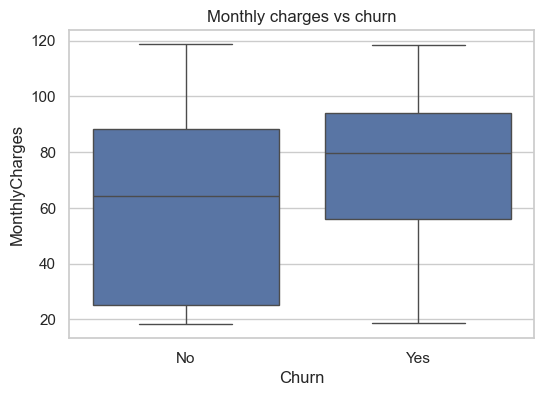

In [7]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly charges vs churn")
plt.show()

#### Churners genrally pay more than stayers i.e the highest risk window is the first few months


In [8]:
print("Median tenure:")
print(df.groupby("Churn")["tenure"].median())
print("\nMedian monthly charges:")
print(df.groupby("Churn")["MonthlyCharges"].median())

Median tenure:
Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64

Median monthly charges:
Churn
No     64.425
Yes    79.650
Name: MonthlyCharges, dtype: float64


## EDA findings
- Dataset is imbalanced: 26.5% churn → will use recall / ROC-AUC, not accuracy.
- Contract type is the strongest signal: month-to-month churns way more than two-year , one year.
- New customers churn most (low tenure), loyalty builds over time.
- Higher monthly charges correlate with churn.
- `TotalCharges` is stored as text with some blanks → must clean 

In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


# Preprocessing 

#### Fixing Total Charges

In [10]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing after conversion:", df["TotalCharges"].isna().sum()) # who havent billed yet 
df["TotalCharges"] = df["TotalCharges"].fillna(0)

Missing after conversion: 11


#### Encoding and target column to prevent answer leakage into input

In [11]:
df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)
X = df.drop(columns=["customerID", "Churn", "ChurnFlag"])
y = df["ChurnFlag"]
print(X.shape, y.shape)

(7043, 19) (7043,)


#### Splitting the data

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print("Train churn rate:", y_train.mean().round(3))
print("Test churn rate:", y_test.mean().round(3))

Train churn rate: 0.265
Test churn rate: 0.265


#### seprating columns which need scaling and which need encoding


In [13]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
categorical_cols = [c for c in X.columns if c not in numeric_cols]
print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


#### Scaled numeric features , one hot encoded categorical features

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(X_train_transformed.shape, X_test_transformed.shape)

(5634, 45) (1409, 45)


## Preprocessing complete
- Fixed TotalCharges ,converted to numeric and filled 11 blanks with 0
- Stratified 80/20 train-test split — churn ratio preserved in both
- Scaled numeric features, one-hot encoded categorical features
- Fit only on training data to avoid leakage

### Baseline Model - Logistic regression

In [16]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_transformed, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [17]:
y_pred = log_reg.predict(X_test_transformed)
y_proba = log_reg.predict_proba(X_test_transformed)[:, 1]

In [18]:
y_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(1409,))

In [19]:
y_proba

array([0.11772432, 0.85189963, 0.14625052, ..., 0.33617168, 0.01319659,
       0.01776963], shape=(1409,))

In [21]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_score, recall_score, f1_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["Stay", "Churn"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))

Confusion Matrix:
[[747 288]
 [ 81 293]]

              precision    recall  f1-score   support

        Stay       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8416


## Baseline (Logistic Regression)
- class_weight="balanced" used to handle the 26.5% churn imbalance
- Evaluated on recall/precision/F1/ROC-AUC — not accuracy
- This baseline number is what Random Forest and XGBoost (next) need to beat
## Baseline results 
- ROC-AUC: 0.8416
- Churn recall: 0.78, precision: 0.50, F1: 0.61
- Baseline is solid — Random Forest, XGBoost needs to beat AUC 0.84

#### Beat log reg baseline with ensemble models and pick a winner properly using cross validation

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
)
rf.fit(X_train_transformed, y_train)

rf_pred = rf.predict(X_test_transformed)
rf_proba = rf.predict_proba(X_test_transformed)[:, 1]

print("Random Forest ROC-AUC:", round(roc_auc_score(y_test, rf_proba), 4))
print(classification_report(y_test, rf_pred, target_names=["Stay", "Churn"]))

Random Forest ROC-AUC: 0.8196
              precision    recall  f1-score   support

        Stay       0.86      0.82      0.83      1035
       Churn       0.55      0.62      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.77      0.76      0.77      1409



In [23]:
from xgboost import XGBClassifier

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print("scale_pos_weight:", round(scale_pos_weight, 2))

xgb = XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss", random_state=42, n_jobs=-1
)
xgb.fit(X_train_transformed, y_train)

xgb_pred = xgb.predict(X_test_transformed)
xgb_proba = xgb.predict_proba(X_test_transformed)[:, 1]

print("XGBoost ROC-AUC:", round(roc_auc_score(y_test, xgb_proba), 4))
print(classification_report(y_test, xgb_pred, target_names=["Stay", "Churn"]))

scale_pos_weight: 2.77
XGBoost ROC-AUC: 0.8379
              precision    recall  f1-score   support

        Stay       0.90      0.75      0.82      1035
       Churn       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



In [24]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in [("LogReg", log_reg), ("RandomForest", rf), ("XGBoost", xgb)]:
    scores = cross_val_score(model, X_train_transformed, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    print(f"{name:<15} CV-AUC: {scores.mean():.4f} ± {scores.std():.4f}")

LogReg          CV-AUC: 0.8460 ± 0.0124
RandomForest    CV-AUC: 0.8233 ± 0.0114
XGBoost         CV-AUC: 0.8423 ± 0.0099


In [25]:
import pandas as pd

results = pd.DataFrame([
    {"Model": "LogisticRegression", "Test_AUC": roc_auc_score(y_test, y_proba),
     "Recall": recall_score(y_test, y_pred), "Precision": precision_score(y_test, y_pred)},
    {"Model": "RandomForest", "Test_AUC": roc_auc_score(y_test, rf_proba),
     "Recall": recall_score(y_test, rf_pred), "Precision": precision_score(y_test, rf_pred)},
    {"Model": "XGBoost", "Test_AUC": roc_auc_score(y_test, xgb_proba),
     "Recall": recall_score(y_test, xgb_pred), "Precision": precision_score(y_test, xgb_pred)},
]).round(4)

results

,Model,Test_AUC,Recall,Precision
0,LogisticRegression,0.8416,0.7834,0.5043
1,RandomForest,0.8196,0.6176,0.5474
2,XGBoost,0.8379,0.7674,0.5237


### Tuning XGBOOST with GridSearchCV

In [26]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.03, 0.05, 0.1],
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    random_state=42, n_jobs=-1
)

grid_search = GridSearchCV(xgb_base, param_grid, scoring="roc_auc", cv=cv, n_jobs=-1)
grid_search.fit(X_train_transformed, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV-AUC:", round(grid_search.best_score_, 4))

xgb_tuned = grid_search.best_estimator_
xgb_tuned_pred = xgb_tuned.predict(X_test_transformed)
xgb_tuned_proba = xgb_tuned.predict_proba(X_test_transformed)[:, 1]
print("Test AUC:", round(roc_auc_score(y_test, xgb_tuned_proba), 4))
print(classification_report(y_test, xgb_tuned_pred, target_names=["Stay", "Churn"]))

Best params: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 300}
Best CV-AUC: 0.8476
Test AUC: 0.845
              precision    recall  f1-score   support

        Stay       0.90      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

